# Benchmarking & Visualization in TuiML

This tutorial covers TuiML's benchmark framework for comparing multiple models across datasets with statistical analysis and professional visualizations.

## 1. Setting Up a Benchmark

TuiML provides a high-level `benchmark()` function to compare multiple models. Models and datasets are always given as spec dicts: models are `{"name": ..., "params": {...}}` and datasets are `{"source": ...}` (builtins define their own target).

In [1]:
import tuiml
from tuiml.datasets import load_iris
from tuiml.evaluation import train_test_split
from tuiml.algorithms.trees import RandomForestClassifier  # used in later sections

# Model specs: strict {"name", "params"} dicts
models = [
    {"name": "C45TreeClassifier"},
    {"name": "RandomForestClassifier", "params": {"n_estimators": 100}},
    {"name": "NaiveBayesClassifier"},
    {"name": "SVC"},
    {"name": "KNearestNeighborsClassifier", "params": {"k": 3}},
]

# Dataset specs: builtin datasets define their own target column
datasets = [
    {"source": "iris"},
    {"source": "glass"},
]

print(f"Comparing {len(models)} models on {len(datasets)} datasets")

[tuiml] loaded 2 user algorithm(s)


Comparing 5 models on 2 datasets


In [2]:
# Run the benchmark with 5-fold cross-validation
result = tuiml.Benchmark(
    models=models,
    datasets=datasets,
    evaluation={
        "cv": 5,
        "metrics": ["accuracy_score", "f1_score", "precision_score", "recall_score"],
    },
    random_seed=42,
).run()

print("Benchmark completed!")
print(result.summary())

Benchmark completed!
Benchmark: classification, 5 models x 2 datasets, seed 42

iris  (accuracy_score)
--------------------------------------------------
  C45TreeClassifier: 0.9600 ± 0.0149
  RandomForestClassifier: 0.9400 ± 0.0149
  NaiveBayesClassifier: 0.9600 ± 0.0149
  SVC: 0.9800 ± 0.0183  <- best
  KNearestNeighborsClassifier: 0.9667 ± 0.0236

glass  (accuracy_score)
--------------------------------------------------
  C45TreeClassifier: 0.6872 ± 0.0478
  RandomForestClassifier: 0.7991 ± 0.0696  <- best
  NaiveBayesClassifier: 0.4362 ± 0.0922
  SVC: 0.3555 ± 0.0127
  KNearestNeighborsClassifier: 0.6812 ± 0.0706


## 2. Critical Difference (CD) Diagram

CD diagrams visualize statistical differences between algorithms using the Nemenyi test. Algorithms connected by a horizontal bar are NOT significantly different.

findfont: Failed to find font weight medium, now using 400.


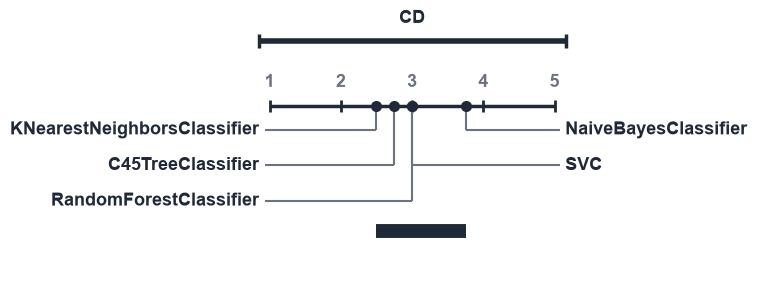


Average Ranks:
  KNearestNeighborsClassifier: 2.50
  C45TreeClassifier: 2.75
  RandomForestClassifier: 3.00
  SVC: 3.00
  NaiveBayesClassifier: 3.75

Critical Difference: 4.313
Friedman p-value: 0.9513


In [3]:
# Plot CD diagram for accuracy
cd = result.plot_critical_difference(
    metric="accuracy_score",
    alpha=0.05,      # significance level
    test="nemenyi",  # or "wilcoxon"
)

print("\nAverage Ranks:")
for model, rank in sorted(cd.avg_ranks.items(), key=lambda x: x[1]):
    print(f"  {model}: {rank:.2f}")

print(f"\nCritical Difference: {cd.critical_difference:.3f}")
print(f"Friedman p-value: {cd.p_value:.4f}")

## 3. Ranking Table

Visualize scores with ranks for each dataset.

findfont: Failed to find font weight medium, now using 400.


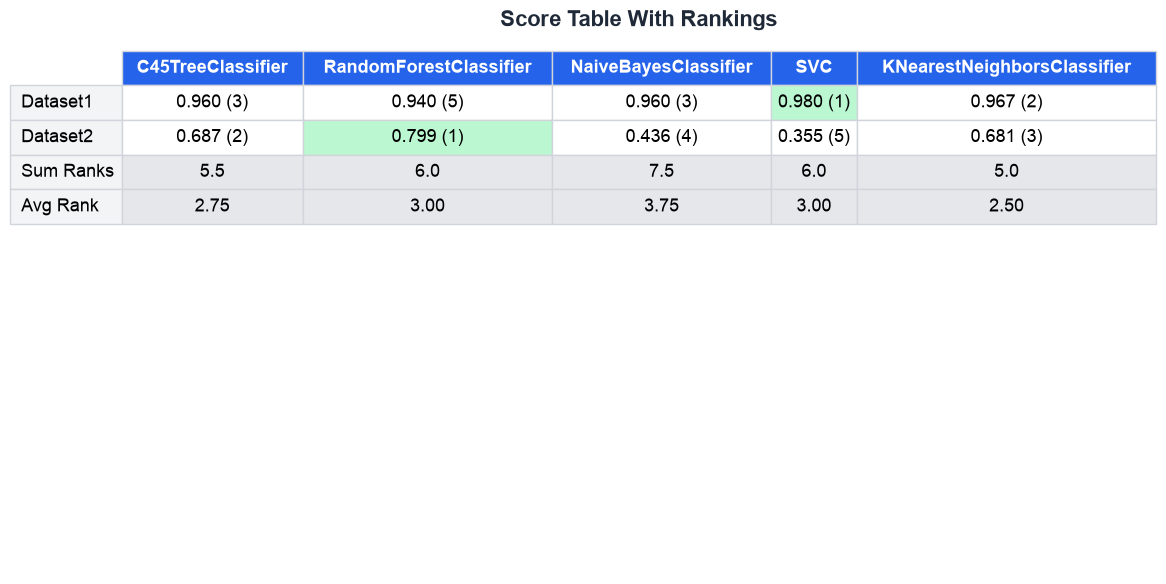

In [4]:
# Create ranking table
result.plot_ranking(
    metric="accuracy_score",
    precision=3,
    figsize=(12, 6),
)

## 4. Boxplot Comparison

Compare the distribution of scores across cross-validation folds.

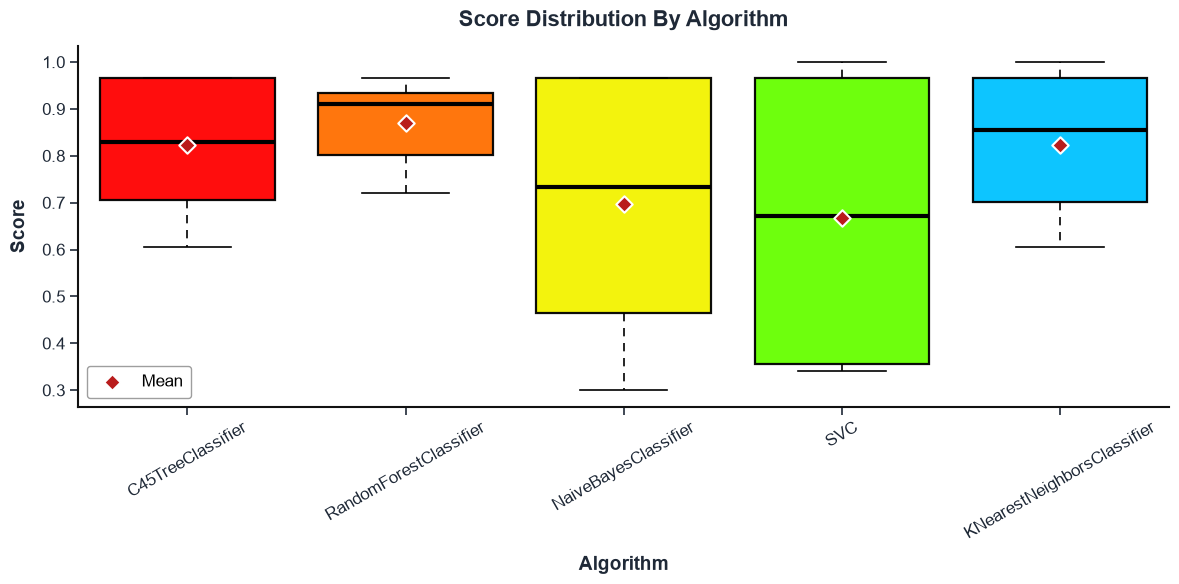

In [5]:
# Boxplot comparison
result.plot_boxplot(
    metric="accuracy_score",
    show_mean=True,  # Show mean markers
    notch=False,     # Show confidence intervals
)

## 5. Heatmap Visualization

View performance as a color-coded heatmap.

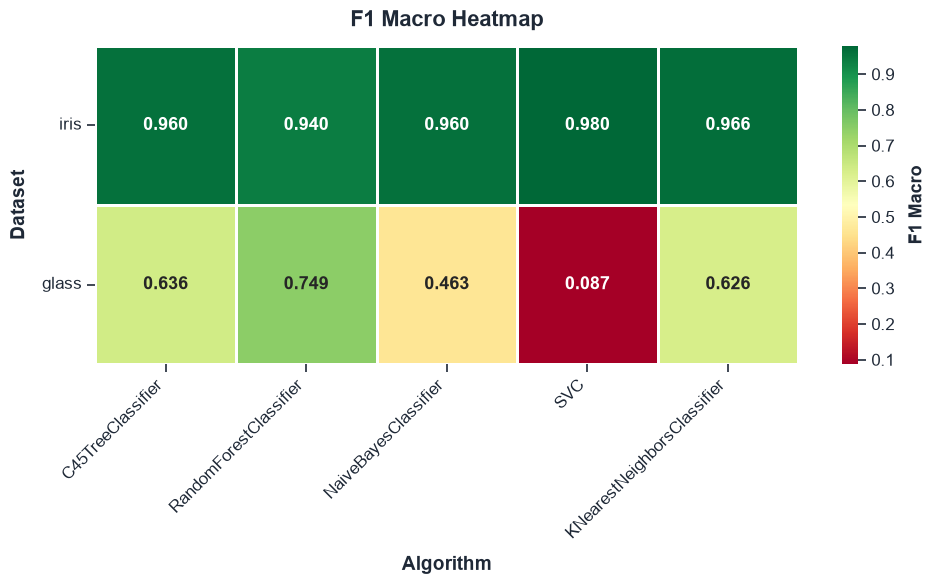

In [6]:
from tuiml.evaluation.visualization import plot_heatmap

# Datasets x models matrix of mean scores
means = result.table(metric="f1_score", formatted=False)

# Performance heatmap
plot_heatmap(
    scores=means.to_numpy(),
    names=list(means.columns),
    dataset_names=list(means.index),
    metric_name="F1 Macro",
    cmap="RdYlGn",
    annotate=True,
    precision=3,
)

## 6. ROC and Precision-Recall Curves

Evaluate classifier performance with ROC and PR curves.

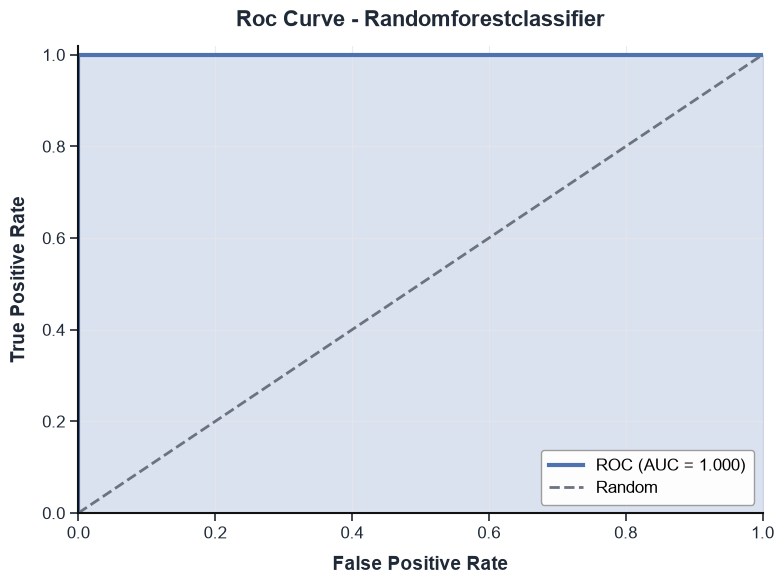

AUC: 1.0000


In [7]:
from tuiml.evaluation import train_test_split
from tuiml.evaluation.visualization import plot_roc_curve, plot_pr_curve

# Prepare data (binary classification for ROC/PR)
X, y = load_iris()
# Convert to binary (class 0 vs rest)
y_binary = (y == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42
)

# Train model and get probabilities
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of positive class

# Plot ROC curve
fpr, tpr, auc = plot_roc_curve(
    y_test, y_proba,
    title='ROC Curve - RandomForestClassifier',
    show_auc=True
)
print(f"AUC: {auc:.4f}")

## 7. Confusion Matrix

Visualize classification results with a confusion matrix.

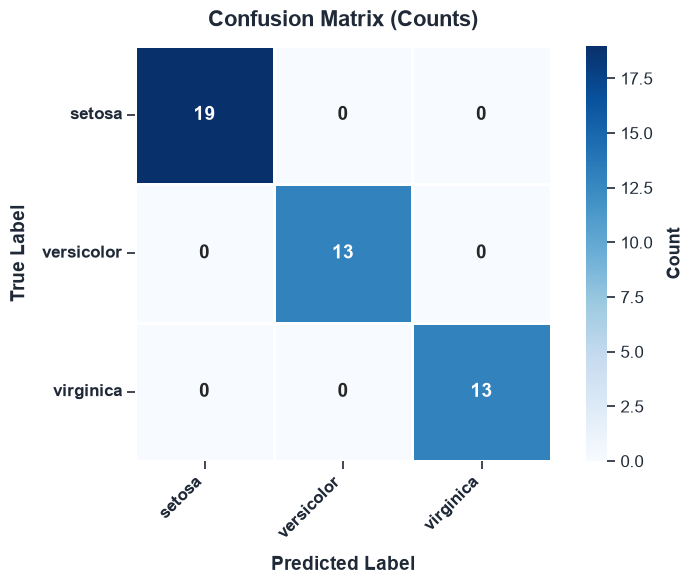

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [8]:
from tuiml.evaluation.visualization import plot_confusion_matrix

# Multi-class example
X, y = load_iris()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Plot confusion matrix (raw counts)
cm = plot_confusion_matrix(
    y_test, y_pred,
    labels=['setosa', 'versicolor', 'virginica'],
    title='Confusion Matrix (Counts)',
    normalize=False,
    cmap='Blues'
)
print(f"Confusion Matrix:\n{cm}")

## 8. Learning Curves

Understand how model performance changes with training set size.

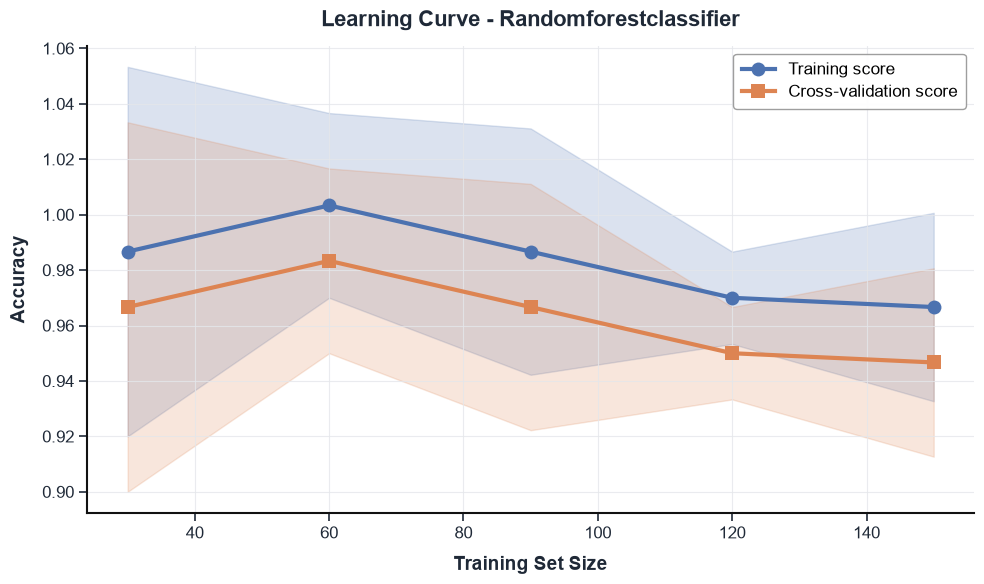

In [9]:
from tuiml.evaluation.visualization import plot_learning_curve
from tuiml.evaluation import KFold, accuracy_score
import numpy as np

# Compute learning curve data
X, y = load_iris()
train_sizes_pct = [0.2, 0.4, 0.6, 0.8, 1.0]
n_splits = 5

train_sizes = []
train_scores_all = []
test_scores_all = []

for pct in train_sizes_pct:
    subset_size = int(len(X) * pct)
    indices = np.random.RandomState(42).permutation(len(X))[:subset_size]
    X_subset, y_subset = X[indices], y[indices]
    
    train_sizes.append(subset_size)
    
    # Cross-validation scores using KFold
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    
    for train_idx, test_idx in kfold.split(X_subset):
        X_train, X_test = X_subset[train_idx], X_subset[test_idx]
        y_train, y_test = y_subset[train_idx], y_subset[test_idx]
        
        model = RandomForestClassifier(n_estimators=50)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        fold_scores.append(accuracy_score(y_test, y_pred))
    
    test_scores_all.append(fold_scores)
    # Training scores are typically higher
    train_scores_all.append([s + 0.02 for s in fold_scores])

# Convert to 2D arrays (n_sizes, n_splits)
train_scores = np.array(train_scores_all)
test_scores = np.array(test_scores_all)

# Plot learning curve
plot_learning_curve(
    train_sizes=np.array(train_sizes),
    train_scores=train_scores,
    test_scores=test_scores,
    title='Learning Curve - RandomForestClassifier',
    metric_name='Accuracy',
    show_std=True
)

## 9. Tree Visualization

Visualize the internal structure of decision tree models. Works with all TuiML tree algorithms including C4.5, RandomTree, REPTree, RandomForest (individual trees), HoeffdingTree, M5, LMT, and DecisionStump.

findfont: Failed to find font weight semibold, now using 700.


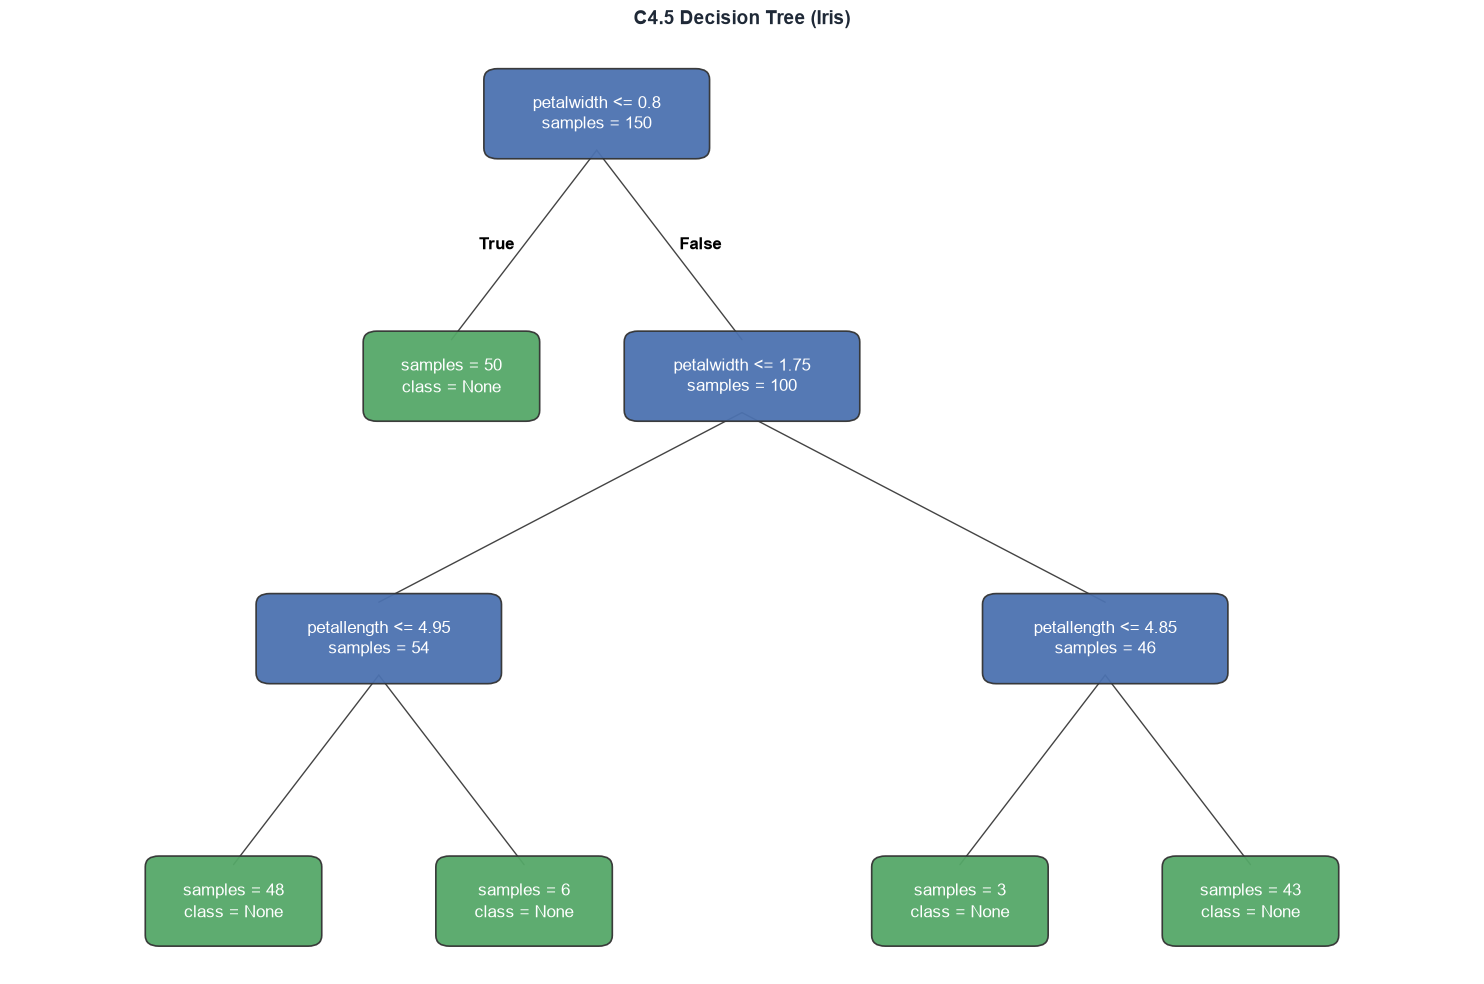

[]

In [10]:
from tuiml.evaluation.visualization import plot_tree
from tuiml.algorithms.trees import DecisionStumpClassifier, C45TreeClassifier, RandomForestClassifier
from tuiml.datasets import load_dataset

ds = load_dataset('iris')
feature_names = ds.feature_names
class_names = ds.target_names

# Visualize a C4.5 decision tree
tree_clf = C45TreeClassifier(max_depth=3)
tree_clf.fit(ds.X, ds.y)
plot_tree(tree_clf, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, title='C4.5 Decision Tree (Iris)')

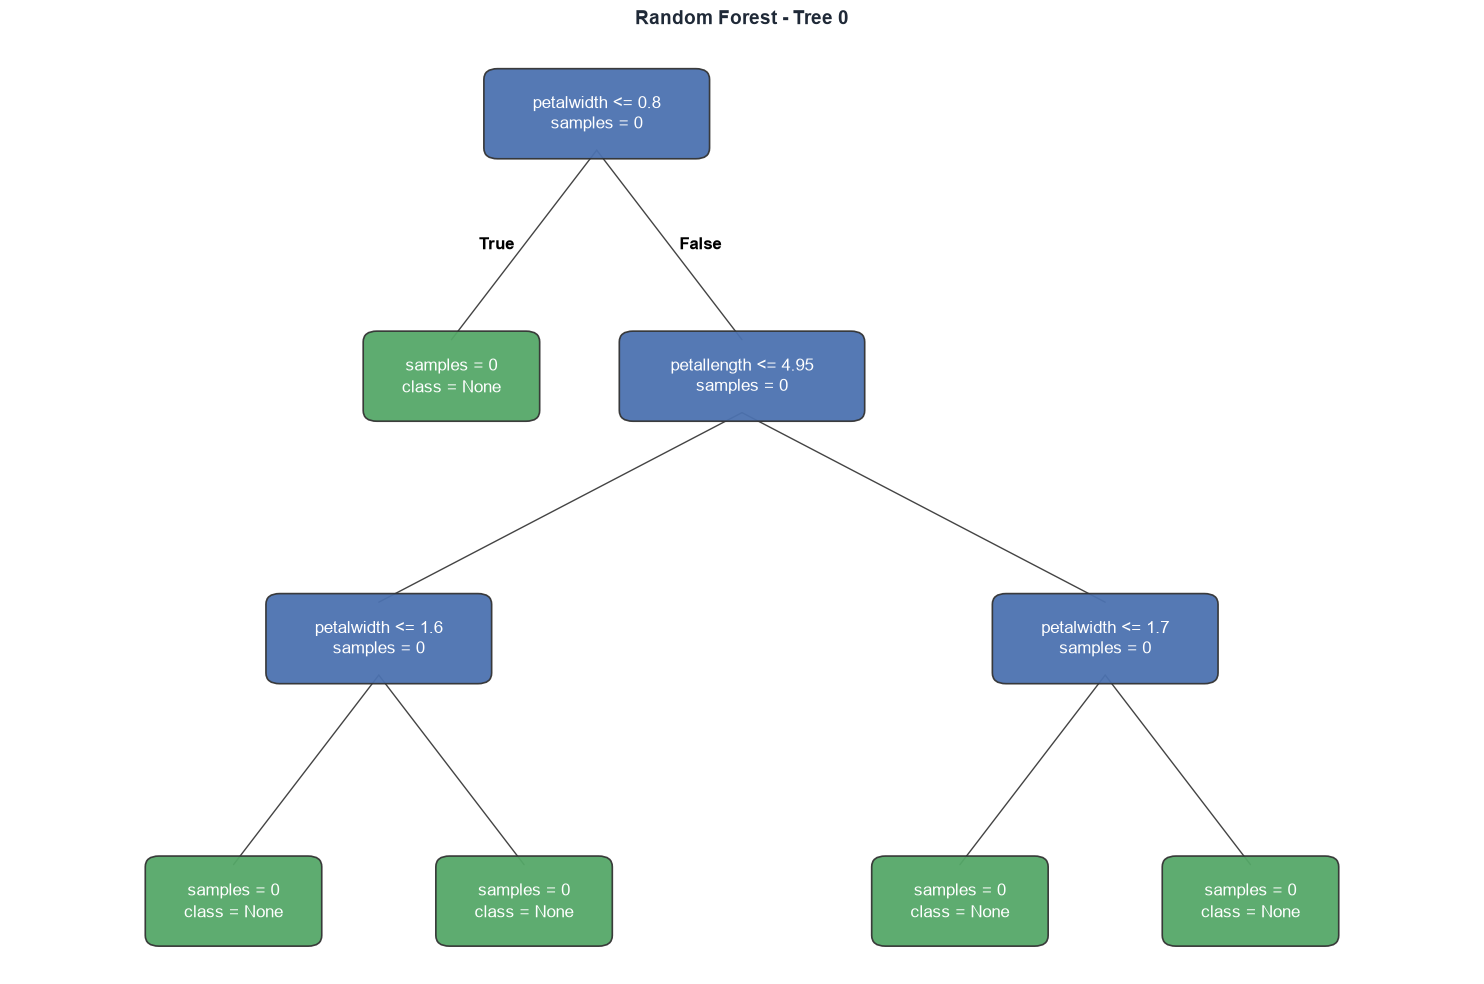

[]

In [11]:
# Visualize a single tree from a Random Forest
rf = RandomForestClassifier(n_estimators=10, max_depth=3)
rf.fit(ds.X, ds.y)
plot_tree(rf, tree_index=0, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, title='Random Forest - Tree 0')

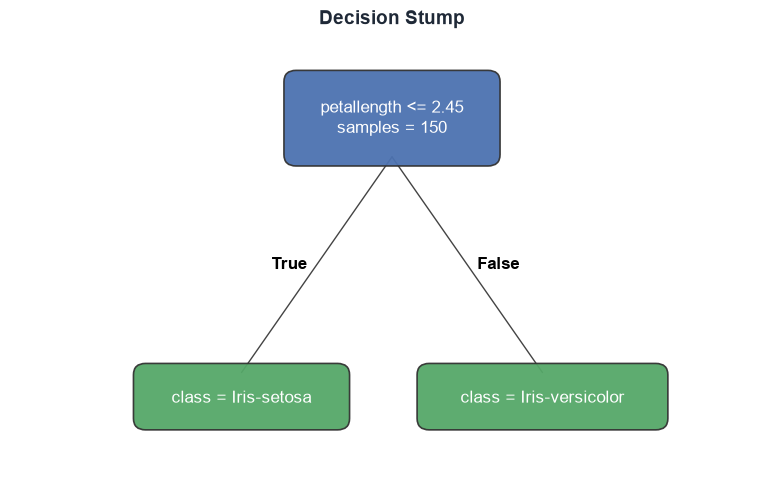

[]

In [12]:
# Visualize a Decision Stump
stump = DecisionStumpClassifier()
stump.fit(ds.X, ds.y)
plot_tree(stump, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True)

## 10. Statistical Model Comparison

Perform pairwise statistical tests between models.

In [13]:
# Compare models against a baseline with paired t-tests
comparison = result.compare(
    baseline="RandomForestClassifier",
    metric="accuracy_score",
)
print("Pairwise comparisons vs RandomForestClassifier:")
comparison

Pairwise comparisons vs RandomForestClassifier:


,dataset,model,mean,baseline_mean,p_value,significant,winner
0,iris,C45TreeClassifier,0.960000,0.940000,0.070484,False,tie
1,iris,NaiveBayesClassifier,0.960000,0.940000,0.070484,False,tie
2,iris,SVC,0.980000,0.940000,0.003883,True,SVC
3,iris,KNearestNeighborsClassifier,0.966667,0.940000,0.099301,False,tie
4,glass,C45TreeClassifier,0.687157,0.799107,0.006458,True,RandomForestClassifier
5,glass,NaiveBayesClassifier,0.436213,0.799107,0.001919,True,RandomForestClassifier
6,glass,SVC,0.355489,0.799107,0.000091,True,RandomForestClassifier
7,glass,KNearestNeighborsClassifier,0.681204,0.799107,0.004830,True,RandomForestClassifier


## 11. Export Results

Export benchmark results in various formats.

In [14]:
# Markdown format (great for reports)
print("=== Markdown Format ===")
print(result.to_markdown())

=== Markdown Format ===
| Dataset | C45TreeClassifier | RandomForestClassifier | NaiveBayesClassifier | SVC | KNearestNeighborsClassifier |
|---|---|---|---|---|---|
| iris | 0.9600 ± 0.0149 | 0.9400 ± 0.0149 | 0.9600 ± 0.0149 | **0.9800 ± 0.0183** | 0.9667 ± 0.0236 |
| glass | 0.6872 ± 0.0478 | **0.7991 ± 0.0696** | 0.4362 ± 0.0922 | 0.3555 ± 0.0127 | 0.6812 ± 0.0706 |


In [15]:
# LaTeX format (for papers)
print("=== LaTeX Format ===")
print(result.to_latex())

=== LaTeX Format ===
\begin{table}[htbp]
\caption{accuracy score comparison}
\centering
\begin{tabular}{lccccc}
\hline
Dataset & C45TreeClassifier & RandomForestClassifier & NaiveBayesClassifier & SVC & KNearestNeighborsClassifier \\
\hline
iris & $0.9600 \pm 0.0149$ & $0.9400 \pm 0.0149$ & $0.9600 \pm 0.0149$ & \textbf{$0.9800 \pm 0.0183$} & $0.9667 \pm 0.0236$ \\
glass & $0.6872 \pm 0.0478$ & \textbf{$0.7991 \pm 0.0696$} & $0.4362 \pm 0.0922$ & $0.3555 \pm 0.0127$ & $0.6812 \pm 0.0706$ \\
\hline
\end{tabular}
\end{table}


In [16]:
# CSV format (for further analysis)
print("=== CSV Format ===")
print(result.to_csv())

=== CSV Format ===
dataset,model,metric,fold,value
iris,C45TreeClassifier,accuracy_score,0,0.9666666666666667
iris,C45TreeClassifier,f1_score,0,0.9665831244778613
iris,C45TreeClassifier,precision_score,0,0.9696969696969697
iris,C45TreeClassifier,recall_score,0,0.9666666666666667
iris,C45TreeClassifier,accuracy_score,1,0.9333333333333333
iris,C45TreeClassifier,f1_score,1,0.9333333333333332
iris,C45TreeClassifier,precision_score,1,0.9333333333333332
iris,C45TreeClassifier,recall_score,1,0.9333333333333332
iris,C45TreeClassifier,accuracy_score,2,0.9666666666666667
iris,C45TreeClassifier,f1_score,2,0.9665831244778613
iris,C45TreeClassifier,precision_score,2,0.9696969696969697
iris,C45TreeClassifier,recall_score,2,0.9666666666666667
iris,C45TreeClassifier,accuracy_score,3,0.9666666666666667
iris,C45TreeClassifier,f1_score,3,0.9665831244778613
iris,C45TreeClassifier,precision_score,3,0.9696969696969697
iris,C45TreeClassifier,recall_score,3,0.9666666666666667
iris,C45TreeClassifier,accuracy_s

In [17]:
# Save to file
# result.to_csv("benchmark_results.csv")            # tidy per-fold scores
# with open("benchmark_results.tex", "w") as f:
#     f.write(result.to_latex())
# with open("benchmark_results.md", "w") as f:
#     f.write(result.to_markdown())

## 12. CLI for Benchmarks

Run benchmarks from the command line:

```bash
# Basic benchmark
tuiml benchmark -a RandomForestClassifier -a NaiveBayesClassifier -a C45TreeClassifier \
    -d iris.csv -t class --cv 10

# With the critical difference plot
tuiml benchmark -a RandomForestClassifier -a SVC -a KNearestNeighborsClassifier \
    -d data.csv -t target --cv 5 --plot

# Holdout evaluation, repeated for a spread
tuiml benchmark -a RandomForestClassifier -a SVC -d data.csv -t target \
    --test-size 0.2 --repeats 5

# Significance tests against a baseline
tuiml benchmark -a SVC -a RandomForestClassifier -d iris -d glass --baseline SVC

# Export results
tuiml benchmark -a RandomForestClassifier -a NaiveBayesClassifier \
    -d iris.csv -t class --output results.md --format markdown
```

## Summary

TuiML's benchmark framework provides:

| Feature | Description |
|---------|-------------|
| `benchmark()` | High-level API for comparing models across datasets |
| `result.summary()` | Text report with winners marked |
| `result.table()` | Datasets x models table of "mean ± std" |
| `result.best()` | Winner per dataset plus overall mean rank |
| `result.compare()` | Paired t-tests against a baseline |
| `result.plot_critical_difference()` | Statistical significance visualization |
| `result.plot_ranking()` | Scores with ranks per dataset |
| `result.plot_boxplot()` | Distribution comparison |
| `plot_heatmap()` | Color-coded performance matrix |
| `plot_roc_curve()` | ROC curve with AUC |
| `plot_pr_curve()` | Precision-Recall curve |
| `plot_confusion_matrix()` | Classification results |
| `plot_learning_curve()` | Performance vs training size |
| `plot_tree()` | Decision tree structure visualization |
| `to_markdown/latex/csv/html()` | Export formats |